In [17]:
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt

torch.manual_seed(42)


X_class0 = torch.randn(50,2) + torch.tensor([-2.0, -2.0])

X_class1 = torch.randn(50,2) + torch.tensor([2.0, 2.0])

X_train = torch.cat([X_class0, X_class1],dim = 0)

y_train =torch.cat([torch.zeros(50),torch.ones(50)])

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: torch.Size([100, 2])
y_train shape: torch.Size([100])


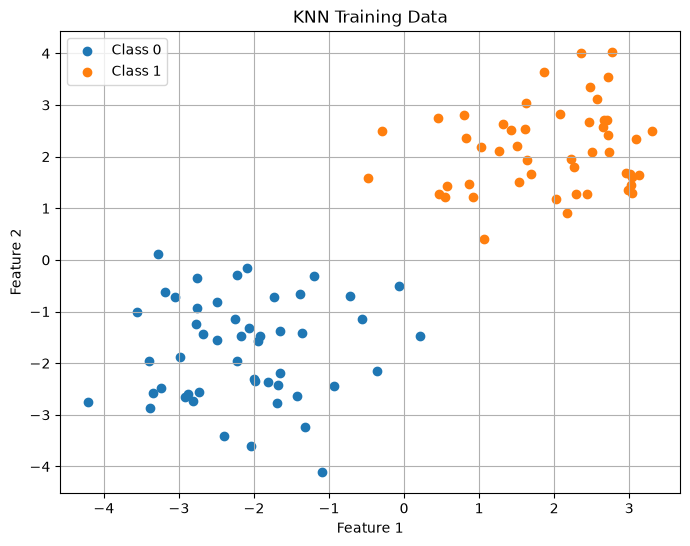

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_class0[:, 0],
    X_class0[:, 1],
    label="Class 0"
)

plt.scatter(
    X_class1[:, 0],
    X_class1[:, 1],
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KNN Training Data")

plt.legend()
plt.grid(True)

plt.show()

In [19]:
def knn_predict(X_train, y_train, X_test, k=3):

    predictions = []

    # Go through every test point
    for test_point in X_test:

        distances = torch.sqrt(
            ((X_train - test_point) ** 2).sum(dim=1)
        )

        _, indices = torch.topk(
            distances,
            k=k,
            largest=False
        )

        # Get their labels
        nearest_labels = y_train[indices]

        prediction = torch.mode(
            nearest_labels
        ).values

        predictions.append(prediction)

    return torch.stack(predictions)

In [20]:
X_test = torch.tensor([
    [-2.0, -1.5],
    [2.0, 2.5],
    [0.0, 0.0],
    [3.0, 1.5]
])

predictions = knn_predict(
    X_train,
    y_train,
    X_test,
    k=5
)

print("Predictions:")
print(predictions)

Predictions:
tensor([0., 1., 0., 1.])


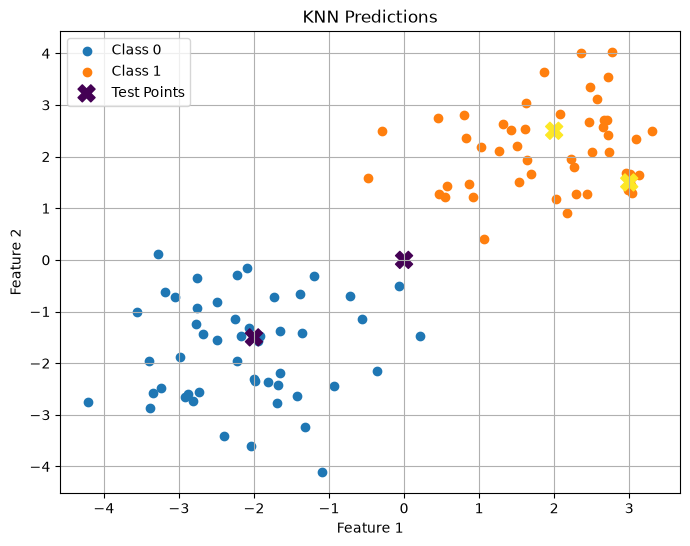

In [21]:
plt.figure(figsize=(8, 6))

# Training data
plt.scatter(
    X_class0[:, 0],
    X_class0[:, 1],
    label="Class 0"
)

plt.scatter(
    X_class1[:, 0],
    X_class1[:, 1],
    label="Class 1"
)

# Test points
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=predictions,
    marker="X",
    s=150,
    label="Test Points"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KNN Predictions")

plt.legend()
plt.grid(True)

plt.show()

In [22]:
predictions = knn_predict(
    X_train,
    y_train,
    X_train,
    k=5
)

accuracy = (predictions == y_train).float().mean()

print(f"Accuracy: {accuracy.item() * 100:.2f}%")

Accuracy: 100.00%


In [23]:
for k in [1, 3, 5, 7, 11]:

    predictions = knn_predict(
        X_train,
        y_train,
        X_test,
        k=k
    )

    print(f"K = {k}")
    print(predictions)
    print()

K = 1
tensor([0., 1., 0., 1.])

K = 3
tensor([0., 1., 0., 1.])

K = 5
tensor([0., 1., 0., 1.])

K = 7
tensor([0., 1., 0., 1.])

K = 11
tensor([0., 1., 0., 1.])

